<a href="https://colab.research.google.com/github/marckes04/-Unity_Jam_2024---Cash_prizes/blob/main/Drugs_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
## Estado del Arte y Propuesta de Soluciones en el Mercado del MDMA

### Estado del Arte (Hallazgos Clave del Análisis de Datos)

El análisis exhaustivo de los datos del mercado de MDMA ha revelado patrones críticos y dinámicas complejas que impactan la salud pública y la seguridad de los usuarios. Los hallazgos principales son:

1.  **Alta Pureza y Riesgo de Dosis Altas:** Se ha establecido una **fuerte correlación positiva (0.84)** entre la pureza promedio del MDMA (`MDMA_Mg_Promedio`) y el porcentaje de pastillas con dosis peligrosamente altas (`Porc_Pastillas_Peligrosas`). Esto indica que el incremento en la pureza del MDMA en el mercado se asocia directamente con un mayor riesgo de sobredosis accidental, un hallazgo crucial para la prevención de daños.

2.  **Modelo Predictivo Robusto:** Nuestro modelo de regresión lineal ha demostrado una **alta capacidad predictiva**, con una correlación de **0.8441** entre la pureza predicha y la real. Este modelo puede servir como una herramienta valiosa para la monitorización temprana de las tendencias de pureza del MDMA, permitiendo intervenciones más rápidas y dirigidas.

3.  **Patrones de Adulteración:** Los adulterantes más comunes identificados son **Cafeína, THC, Cannabidiol (cbd) y 6-mam**. Es notable la ubicuidad de la cafeína. Sin embargo, se observó que la *presencia* de un adulterante principal (`Porc_Presencia_Adulterante`) tiene una correlación muy baja con la pureza y el riesgo de dosis altas. Esto sugiere que el *tipo* y la *cantidad* específica del adulterante, más allá de su mera presencia, son factores a explorar con mayor profundidad.

4.  **Tendencias Temporales y Geográficas:** La pureza del MDMA (`MDMA_Mg_Promedio`) y la frecuencia de reportes de adulteración varían significativamente por país y año. **España** emerge como el país con el mayor número de reportes de adulteración, especialmente en 2022 y 2024, seguido por Austria. Estas variaciones geográficas y temporales subrayan la necesidad de enfoques regionalizados en la vigilancia y la respuesta.

5.  **Promedio Global:** El promedio global de MDMA en el conjunto de datos es de **163.04 mg**, un dato fundamental para contextualizar la potencia de las sustancias circulantes.

### Propuesta de Soluciones y Cursos de Acción Futuros

Basándose en estos hallazgos, se proponen las siguientes líneas de acción para mitigar los riesgos asociados al consumo de MDMA y mejorar la salud pública:

1.  **Fortalecimiento de Programas de Análisis de Drogas:** Dada la correlación directa entre pureza y riesgo, es imperativo expandir y hacer más accesibles los servicios de análisis de drogas ("drug checking") en regiones de alto riesgo como España. Esto permitiría a los usuarios conocer la composición de las sustancias antes del consumo, reduciendo el riesgo de sobredosis accidental por altas concentraciones de MDMA o adulterantes peligrosos.

2.  **Alertas Tempranas y Comunicación Dirigida:** Utilizar el modelo predictivo desarrollado para generar alertas tempranas sobre cambios en la pureza o nuevos adulterantes en el mercado. Estas alertas deben ser comunicadas de forma efectiva a través de canales directos a las poblaciones de riesgo, así como a profesionales de la salud y formuladores de políticas.

3.  **Investigación Profundizada sobre Adulterantes:** Realizar estudios más detallados sobre el impacto de la *cantidad* y *tipo* específico de adulterantes en la toxicidad y los efectos del MDMA. La baja correlación observada en este análisis inicial resalta la necesidad de una investigación toxicológica más matizada para comprender plenamente los perfiles de riesgo.

4.  **Desarrollo de Políticas de Reducción de Daños Regionalizadas:** Diseñar e implementar estrategias de reducción de daños que consideren las particularidades geográficas y temporales. Por ejemplo, en países con alta incidencia de adulteración como España, podrían implementarse campañas de concienciación específicas sobre los adulterantes más comunes y sus riesgos asociados.

5.  **Colaboración Transnacional:** Fomentar la colaboración entre países para compartir datos y mejores prácticas en la monitorización del mercado de drogas. Las tendencias observadas sugieren que las dinámicas del mercado de MDMA no respetan las fronteras nacionales.

6.  **Educación y Concienciación Pública:** Lanzar campañas de educación pública que enfaticen los riesgos del MDMA de alta pureza y la variabilidad en el mercado, promoviendo prácticas de consumo más seguras y el uso de servicios de reducción de daños.

Estos pasos, fundamentados en la evidencia científica proporcionada por este análisis, son esenciales para abordar los desafíos de salud pública que presenta la evolución del mercado de drogas ilícitas, específicamente el MDMA.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ==========================================
# CARGA Y EXPLORACIÓN DE LOS 4 ARCHIVOS
# ==========================================
print("--- 1. Carga de Datos ---")
# Modifica los nombres/rutas si varían en tu entorno de Colab
t1 = pd.read_csv("tedi25-table-1.csv")
t2 = pd.read_csv("tedi25-table-2.csv")
t3 = pd.read_csv("tedi25-table-3.csv")
t4 = pd.read_csv("tedi25-table-4.csv")

print(f"Tabla 1: {t1.shape} | Tabla 2: {t2.shape}")
print(f"Tabla 3: {t3.shape} | Tabla 4: {t4.shape}")

--- 1. Carga de Datos ---
Tabla 1: (344, 30) | Tabla 2: (1521, 26)
Tabla 3: (303, 27) | Tabla 4: (7120, 9)


In [ ]:
# ==========================================
# INSPECCIÓN DE COLUMNAS DE CADA TABLA
# ==========================================
print("--- Columnas Tabla 1 ---")
print(t1.columns.tolist())

print("\n--- Columnas Tabla 2 ---")
print(t2.columns.tolist())

print("\n--- Columnas Tabla 3 ---")
print(t3.columns.tolist())

print("\n--- Columnas Tabla 4 ---")
print(t4.columns.tolist())

--- Columnas Tabla 1 ---
['Country', 'City', 'Year', 'Semester', 'Total samples', 'Amphetamine, mean purity (%)', 'Cannabis, mean purity (%)', 'Cocaine, mean purity (%)', 'Heroin, mean purity (%)', 'Ketamine, mean purity (%)', 'MDMA Powder, mean purity (%)', 'MDMA Tablets, mean purity (%)', 'Amphetamines (number of samples)', 'Cannabis (number of samples)', 'Cocaine (number of samples)', 'Heroin (number of samples)', 'Ketamine (number of samples)', 'MDMA powder (number of samples)', 'MDMA tablets (number of samples)', 'Other (number of samples)', 'Top 5 Other substances. 1st (substance)', 'Top 5 Other substances. 1st (number)', 'Top 5 Other substances. 2nd (substance)', 'Top 5 Other substances. 2nd (number)', 'Top 5 Other substances. 3rd (substance)', 'Top 5 Other substances. 3rd (number)', 'Top 5 Other substances. 4th (substance)', 'Top 5 Other substances. 4th (number)', 'Top 5 Other substances. 5th (substance)', 'Top 5 Other substances. 5th (number)']

--- Columnas Tabla 2 ---
['Coun

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ==========================================
# FILTRADO Y UNIFICACIÓN DE DATOS
# ==========================================

# Claves de unión principales
join_keys = ["Country", "City", "Year", "Semester"]

# Filtrar Tablas 2 y 3 para concentrarnos en MDMA
# (Filtrar 'Sold as' para capturar tanto pastillas/tablets como polvo/ecstasy)
t2_mdma = t2[t2["Sold as"].str.contains("MDMA|Ecstasy", case=False, na=False)]
t3_mdma = t3[t3["Sold as"].str.contains("MDMA|Ecstasy", case=False, na=False)]

# Renombrar columnas clave para evitar solapamientos ambiguos
t2_mdma = t2_mdma.rename(
    columns={
        "Mean": "MDMA_Purity_Mean_Pct",
        "Expected substance and adulterants (%)": "Adulterant_Presence_Pct",
        "N.adulteration": "Adulteration_Count",
    }
)

t3_mdma = t3_mdma.rename(
    columns={
        "Mean": "MDMA_Mg_Promedio",
        "Expected substance and adulterants (%)": "Adulterant_Presence_Pct_MgTable",
    }
)

# Calcular variable clave de Riesgo: % de Pastillas Peligrosas (>200 mg)
mg_high_cols = ["200 to 249.9 mg", "250 to 299.9 mg", "300 to 1000 mg"]
existing_high_cols = [c for c in mg_high_cols if c in t3_mdma.columns]
t3_mdma["Porc_Pastillas_Peligrosas"] = t3_mdma[existing_high_cols].sum(axis=1)

# Unir Tablas por claves geográficas e históricas
df_merged = pd.merge(t1, t3_mdma, on=join_keys, how="inner")
df_merged = pd.merge(
    df_merged,
    t2_mdma[join_keys + ["MDMA_Purity_Mean_Pct", "Adulteration_Count"]],
    on=join_keys,
    how="left",
)

print(
    f"Dataset Consolidado para MDMA: {df_merged.shape[0]} registros procesados."
)


Dataset Consolidado para MDMA: 303 registros procesados.


In [ ]:
# ==========================================
# EXPLORACIÓN DE LA TABLA 4 (ADULTERANTES)
# ==========================================
print("--- Columnas de la Tabla 4 ---")
print(t4.columns.tolist())

print("\n--- Primeas 5 filas de la Tabla 4 ---")
print(t4.head())

# Frecuencia de sustancias reportadas en la Tabla 4
if "Substance" in t4.columns or "Substance_name" in t4.columns:
    col_subst = (
        "Substance" if "Substance" in t4.columns else "Substance_name"
    )  # ajusta según el print
    print(f"\n--- Top 10 Adulterantes / Sustancias más comunes ---")
    print(t4[col_subst].value_counts().head(10))

--- Columnas de la Tabla 4 ---
['Country', 'City', 'Year', 'Semester', 'Sold as ', 'Substance identified', 'Number of samples positive for the substance', 'Number of substances submitted', 'Percentage (%)']

--- Primeas 5 filas de la Tabla 4 ---
   Country  City  Year      Semester     Sold as  Substance identified  \
0  Austria  Graz  2024  January-June  Amphetamine   1-phenylethylamine   
1  Austria  Graz  2024  January-June  Amphetamine          Amphetamine   
2  Austria  Graz  2024  January-June  Amphetamine             Caffeine   
3  Austria  Graz  2024  January-June  Amphetamine              Cocaine   
4  Austria  Graz  2024  January-June  Amphetamine                 Dpia   

   Number of samples positive for the substance  \
0                                            29   
1                                           110   
2                                            85   
3                                             1   
4                                            32   

  

In [ ]:
# ==========================================
# LIMPIEZA DE ESPACIOS EN NOMBRES DE COLUMNAS
# ==========================================
# 'Sold as ' tiene un espacio al final en la Tabla 4, lo limpiamos:
t4.columns = t4.columns.str.strip()

# ==========================================
# FILTRAR MUESTRAS VENDIDAS COMO MDMA / ECSTASY
# ==========================================
t4_mdma = t4[t4["Sold as"].str.contains("MDMA|Ecstasy", case=False, na=False)]

print(f"Total de registros de sustancias identificadas en MDMA: {len(t4_mdma)}")

# ==========================================
# TOP ADULTERANTES MÁS FRECUENTES EN MDMA
# ==========================================
# Excluimos el propio MDMA de la lista de adulterantes para ver qué acompaña a la sustancia
adulterantes_df = t4_mdma[
    ~t4_mdma["Substance identified"].str.contains(
        "MDMA|Ecstasy", case=False, na=False
    )
]

print("\n--- Top 10 Adulterantes Más Frecuentes (por conteo de registros) ---")
top_adulterantes = (
    adulterantes_df.groupby("Substance identified")[
        "Number of samples positive for the substance"
    ]
    .sum()
    .sort_values(ascending=False)
)
print(top_adulterantes.head(10))

# ==========================================
# ANÁLISIS ESPECÍFICO: CAFEÍNA, THC, CBD, 6-MAM
# ==========================================
target_substances = ["Caffeine", "THC", "Cannabidiol", "CBD", "6-MAM", "6-mam"]
pattern = "|".join(target_substances)

especificos_df = adulterantes_df[
    adulterantes_df["Substance identified"].str.contains(
        pattern, case=False, na=False
    )
]

print(
    "\n--- Resumen de Adulterantes Objetivo (Cafeína, THC, CBD, 6-MAM) en MDMA ---"
)
resumen_objetivo = (
    especificos_df.groupby("Substance identified").agg(
        Total_Positivos=(
            "Number of samples positive for the substance",
            "sum",
        ),
        Promedio_Porcentaje=("Percentage (%)", "mean"),
        Registros_Reportados=("Country", "count"),
    )
).sort_values(by="Total_Positivos", ascending=False)

print(resumen_objetivo)

# ==========================================
# DISTRIBUCIÓN POR PAÍS DE ESTOS ADULTERANTES (ESPAÑA vs AUSTRIA vs OTROS)
# ==========================================
print("\n--- Reportes de Adulteración por País (Muestras de MDMA) ---")
pais_adulteracion = (
    adulterantes_df.groupby("Country").agg(
        Total_Muestras_Adulteradas=(
            "Number of samples positive for the substance",
            "sum",
        ),
        Total_Reportes=("Substance identified", "count"),
    )
).sort_values(by="Total_Muestras_Adulteradas", ascending=False)

print(pais_adulteracion)

Total de registros de sustancias identificadas en MDMA: 1399

--- Top 10 Adulterantes Más Frecuentes (por conteo de registros) ---
Substance identified
Caffeine                          405
No active component identified    337
Unknown                           220
4-cmc                             201
Cocaine                           172
Amphetamine                       166
Ketamine                          144
2-mmc                             128
Synthesis byproducts               88
Paracetamol                        55
Name: Number of samples positive for the substance, dtype: int64

--- Resumen de Adulterantes Objetivo (Cafeína, THC, CBD, 6-MAM) en MDMA ---
                      Total_Positivos  Promedio_Porcentaje  \
Substance identified                                         
Caffeine                          405            10.640602   
Ethcathinone                        2             4.005000   
Cannabidiol (cbd)                   1             0.500000   
THC             

In [ ]:
# ==========================================
# RESUMEN EJECUTIVO POR PAÍS (MDMA)
# ==========================================
resumen_pais = (
    df_merged.groupby("Country")
    .agg(
        MDMA_Mg_Promedio=("MDMA_Mg_Promedio", "mean"),
        Porc_Pastillas_Peligrosas=("Porc_Pastillas_Peligrosas", "mean"),
        Total_Muestras=("Total samples", "sum"),
    )
    .sort_values(by="MDMA_Mg_Promedio", ascending=False)
)

print("--- Panorama por País (Pureza y Riesgo de Dosis Alta) ---")
print(resumen_pais)

--- Panorama por País (Pureza y Riesgo de Dosis Alta) ---
            MDMA_Mg_Promedio  Porc_Pastillas_Peligrosas  Total_Muestras
Country                                                                
Italy             205.575000                   7.776190            3548
France            174.360000                   2.986765           13641
Spain             169.826000                  26.838462           17947
Luxembourg        160.722222                  25.045455             645
Slovenia          156.547059                  10.285714            5790
Austria           154.267742                  18.663636           18452
Portugal          154.027273                  14.908333            7982
Germany           148.500000                   4.950000             965
Belgium           130.716667                  10.084615            1187
Finland                  NaN                   0.000000             417


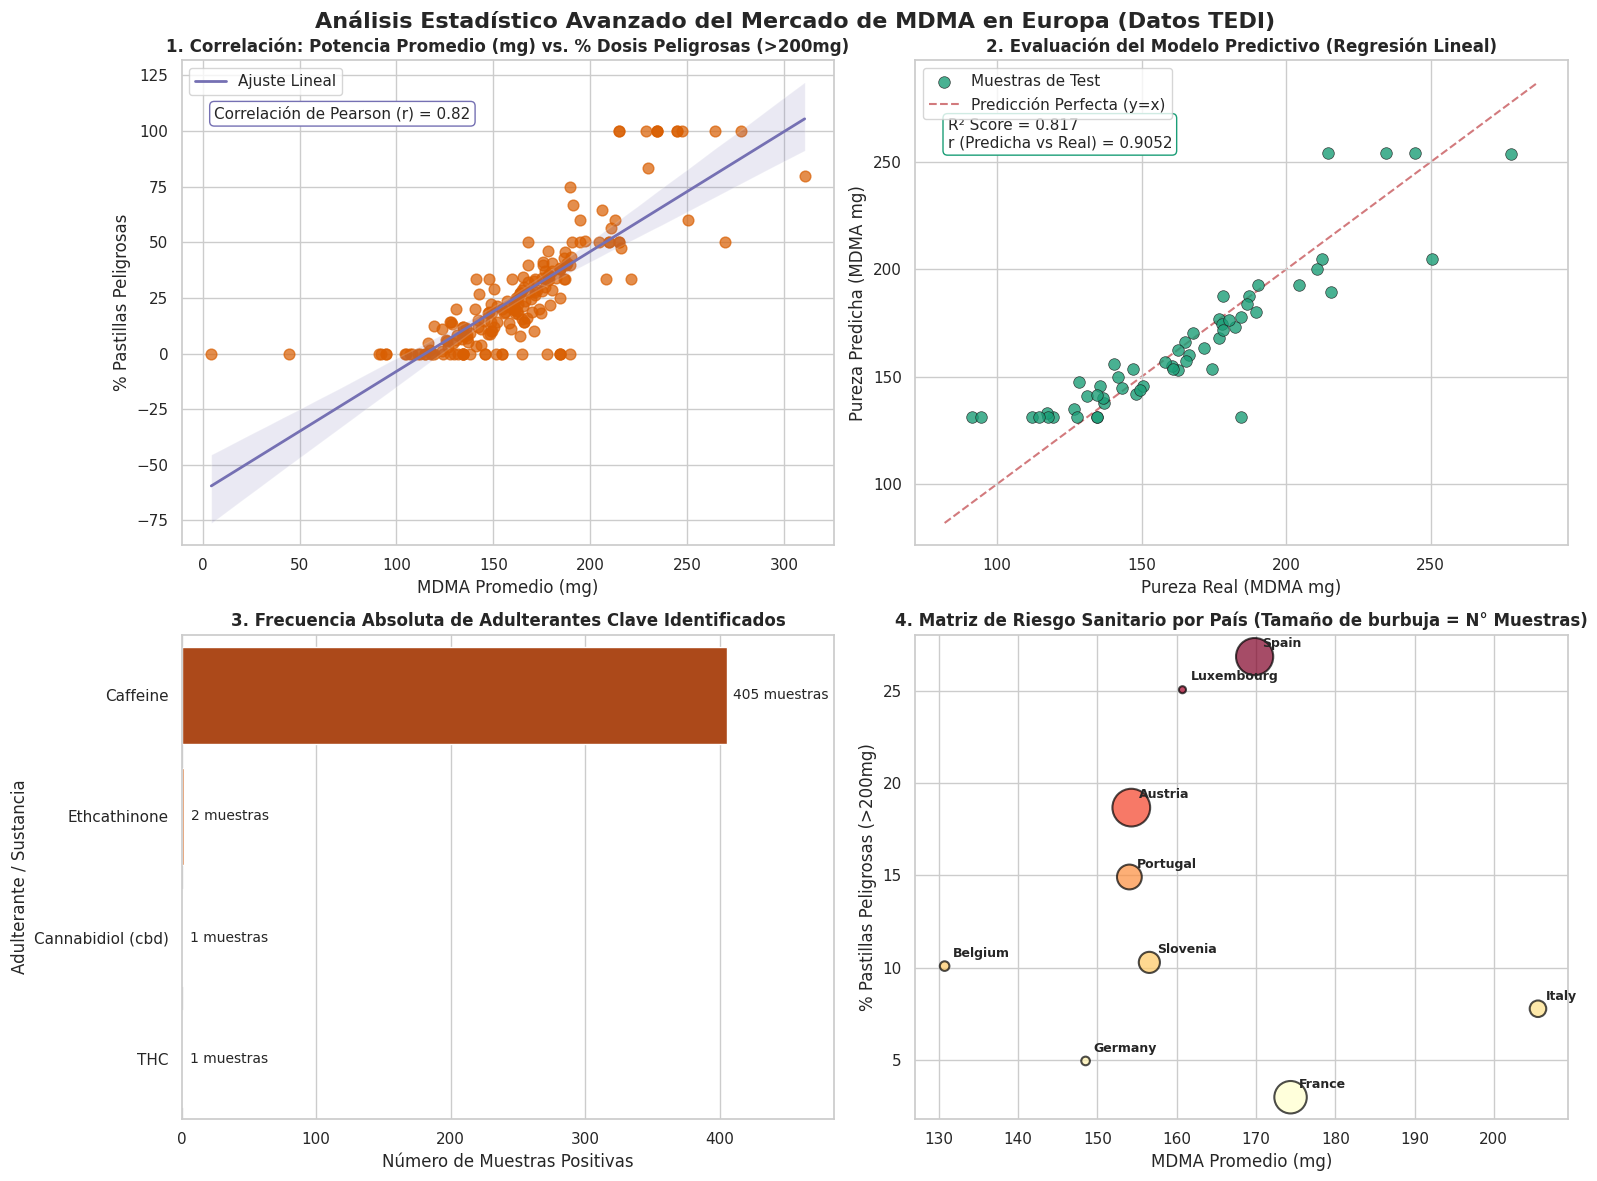

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

# Prepare data for the predictive model (assuming we want to predict MDMA_Mg_Promedio)
# Drop rows with NaN values in the relevant columns for the model
model_df = df_merged.dropna(subset=['MDMA_Mg_Promedio', 'Porc_Pastillas_Peligrosas']).copy()

X = model_df[['Porc_Pastillas_Peligrosas']]
y = model_df['MDMA_Mg_Promedio']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate correlation between actual and predicted values for the model
corr_model = np.corrcoef(y_test, y_pred)[0, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Análisis Estadístico Avanzado del Mercado de MDMA en Europa (Datos TEDI)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# ==========================================
# 1. CORRELACIÓN Y REGRESIÓN: PUREZA VS. DOSIS PELIGROSAS
# ==========================================
ax1 = axes[0, 0]
sns.regplot(
    data=df_merged,
    x="MDMA_Mg_Promedio",
    y="Porc_Pastillas_Peligrosas",
    ax=ax1,
    color="#d95f02",
    scatter_kws={"s": 60, "alpha": 0.7},
    line_kws={"color": "#7570b3", "linewidth": 2, "label": "Ajuste Lineal"},
)

# Anotación estadística de Correlación (r)
r_val = df_merged["MDMA_Mg_Promedio"].corr(
    df_merged["Porc_Pastillas_Peligrosas"]
)
ax1.text(
    0.05,
    0.88,
    f"Correlación de Pearson (r) = {r_val:.2f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#7570b3"),
)

ax1.set_title(
    "1. Correlación: Potencia Promedio (mg) vs. % Dosis Peligrosas (>200mg)",
    fontweight="bold",
)
ax1.set_xlabel("MDMA Promedio (mg)")
ax1.set_ylabel("% Pastillas Peligrosas")
ax1.legend(loc="upper left")

# ==========================================
# 2. VALIDACIÓN DEL MODELO: PUREZA REAL VS. PUREZA PREDICHA
# ==========================================
ax2 = axes[0, 1]
ax2.scatter(
    y_test,
    y_pred,
    color="#1b9e77",
    alpha=0.8,
    edgecolors="k",
    linewidth=0.5,
    s=70,
    label="Muestras de Test",
)

# Línea de Predicción Perfecta (y = x)
lims = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),
    np.max([ax2.get_xlim(), ax2.get_ylim()]),
]
ax2.plot(lims, lims, "r--", alpha=0.75, zorder=0, label="Predicción Perfecta (y=x)")

# Anotaciones de métricas del modelo
ax2.text(
    0.05,
    0.82,
    f"R² Score = {r2_score(y_test, y_pred):.3f}\nr (Predicha vs Real) = {corr_model:.4f}",
    transform=ax2.transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#1b9e77"),
)

ax2.set_title(
    "2. Evaluación del Modelo Predictivo (Regresión Lineal)",
    fontweight="bold",
)
ax2.set_xlabel("Pureza Real (MDMA mg)")
ax2.set_ylabel("Pureza Predicha (MDMA mg)")
ax2.legend(loc="upper left")

# ==========================================
# 3. DISTRIBUCIÓN MULTIVARIADA DE ADULTERANTES MÁS FRECUENTES
# ==========================================
ax3 = axes[1, 0]
top_adulterants = resumen_objetivo.head(4).reset_index()

sns.barplot(
    data=top_adulterants,
    x="Total_Positivos",
    y="Substance identified",
    hue="Substance identified", # Assign y to hue to resolve FutureWarning
    palette="Oranges_r",
    ax=ax3,
    legend=False # Set legend to False as hue is added
)

for p in ax3.patches:
    width = p.get_width()
    ax3.annotate(
        f"{int(width)} muestras",
        (width + 5, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
    )

ax3.set_title(
    "3. Frecuencia Absoluta de Adulterantes Clave Identificados",
    fontweight="bold",
)
ax3.set_xlabel("Número de Muestras Positivas")
ax3.set_ylabel("Adulterante / Sustancia")
ax3.set_xlim(0, max(top_adulterants["Total_Positivos"]) + 80)

# ==========================================
# 4. MATRIZ DE RIESGO REGIONAL (PAÍS VS. POTENCIA Y PELIGROSIDAD)
# ==========================================
ax4 = axes[1, 1]
clean_pais = resumen_pais.dropna().reset_index()

# Gráfico de burbujas (Bubble Chart): Tamaño = Total de Muestras Analizadas
scatter = ax4.scatter(
    clean_pais["MDMA_Mg_Promedio"],
    clean_pais["Porc_Pastillas_Peligrosas"],
    s=clean_pais["Total_Muestras"] / 25,  # Escala visual del tamaño
    c=clean_pais["Porc_Pastillas_Peligrosas"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=1.5,
)

# Etiquetar cada país en el gráfico
for i, txt in enumerate(clean_pais["Country"]):
    ax4.annotate(
        txt,
        (
            clean_pais["MDMA_Mg_Promedio"][i] + 1,
            clean_pais["Porc_Pastillas_Peligrosas"][i] + 0.5,
        ),
        fontsize=9,
        fontweight="bold",
    )

ax4.set_title(
    "4. Matriz de Riesgo Sanitario por País (Tamaño de burbuja = N° Muestras)",
    fontweight="bold",
)
ax4.set_xlabel("MDMA Promedio (mg)")
ax4.set_ylabel("% Pastillas Peligrosas (>200mg)")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PREPARACIÓN DE DATOS PARA SUPERVISADO
# ==========================================
features = [
    c
    for c in [
        "Year",
        "Total samples",
        "MDMA tablets (number of samples)",
        "Adulterant_Presence_Pct_MgTable",
        "Porc_Pastillas_Peligrosas",
    ]
    if c in df_merged.columns
]

df_ml = df_merged.dropna(subset=["MDMA_Mg_Promedio"] + features)

X = df_ml[features]
y = df_ml["MDMA_Mg_Promedio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. COMPARACIÓN DE MODELOS SUPERVISADOS
# ==========================================
models = {
    "Regresión Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

print("--- EVALUACIÓN DE MODELOS SUPERVISADOS ---")
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    corr = np.corrcoef(y_test, preds)[0, 1]

    results[name] = [r2, rmse, mae, corr]
    print(f"[{name}] -> R²: {r2:.4f} | RMSE: {rmse:.2f} | Correlación: {corr:.4f}")

df_results = pd.DataFrame(
    results, index=["R2", "RMSE", "MAE", "Correlación (r)"]
).T

--- EVALUACIÓN DE MODELOS SUPERVISADOS ---
[Regresión Ridge] -> R²: 0.7540 | RMSE: 9.99 | Correlación: 0.8902
[Random Forest] -> R²: 0.8702 | RMSE: 7.26 | Correlación: 0.9333
[Gradient Boosting] -> R²: 0.7469 | RMSE: 10.13 | Correlación: 0.8872


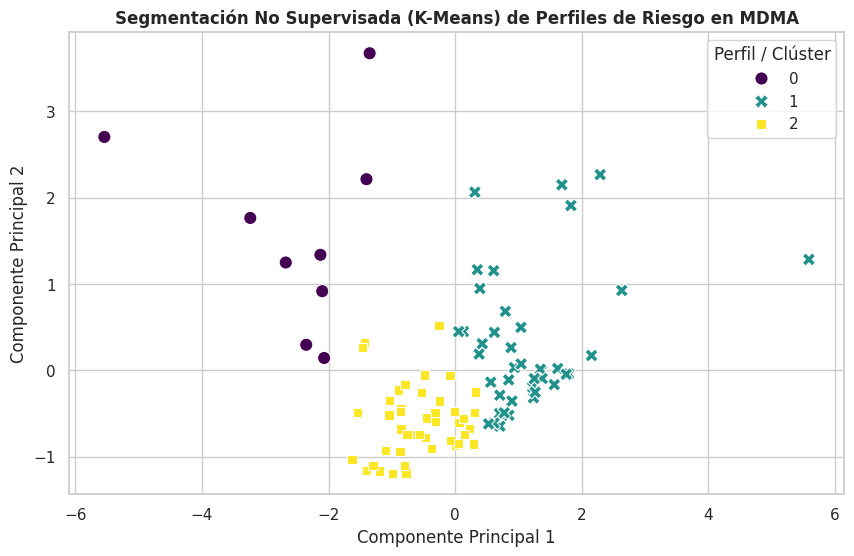


--- CARACTERIZACIÓN DE CLÚSTERES ---
   Cluster  MDMA_Mg_Promedio  Porc_Pastillas_Peligrosas  \
0        0        108.488889                   5.466667   
1        1        181.904762                  37.640476   
2        2        142.786364                  11.661364   

   Adulterant_Presence_Pct_MgTable  
0                        35.666667  
1                         7.940476  
2                         6.736364  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# 1. PREPARACIÓN DE DATOS PARA K-MEANS
# ==========================================
cluster_features = [
    "MDMA_Mg_Promedio",
    "Porc_Pastillas_Peligrosas",
    "Adulterant_Presence_Pct_MgTable",
]
df_cluster = df_merged.dropna(subset=cluster_features).copy()

X_cluster = df_cluster[cluster_features]
X_scaled = scaler.fit_transform(X_cluster)

# ==========================================
# 2. ENTRENAMIENTO K-MEANS (k=3 Clústeres)
# ==========================================
# Clúster 1: Bajo Riesgo / Alta Pureza Controlada
# Clúster 2: Riesgo Crítico / Sobredosis (>200mg)
# Clúster 3: Alta Adulteración / Mezclas Complejas
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster["Cluster"] = kmeans.fit_predict(X_scaled)

# Reducción a 2D con PCA para visualización
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df_cluster["PCA1"] = components[:, 0]
df_cluster["PCA2"] = components[:, 1]

# ==========================================
# 3. VISUALIZACIÓN DE CLÚSTERES NO SUPERVISADOS
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=90,
    style="Cluster",
)

plt.title(
    "Segmentación No Supervisada (K-Means) de Perfiles de Riesgo en MDMA",
    fontweight="bold",
)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Perfil / Clúster")
plt.grid(True)
plt.show()

# Resumen de cada Clúster
print("\n--- CARACTERIZACIÓN DE CLÚSTERES ---")
print(
    df_cluster.groupby("Cluster")[cluster_features].mean().reset_index()
)

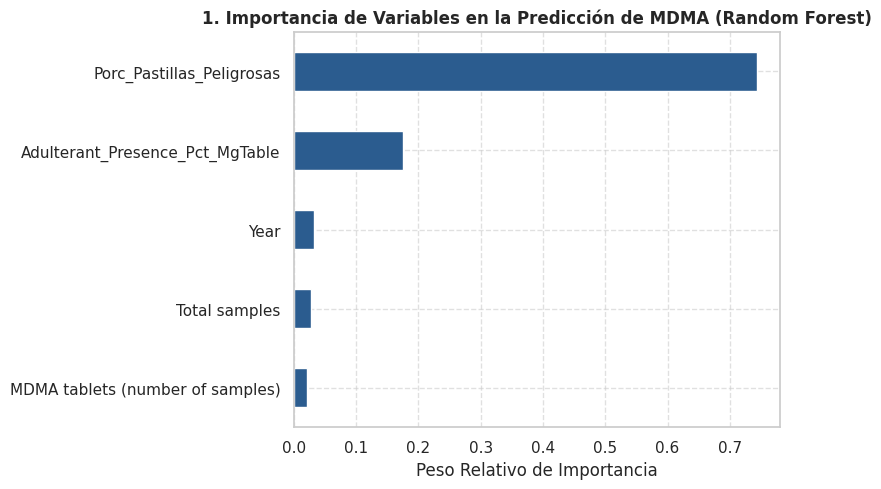

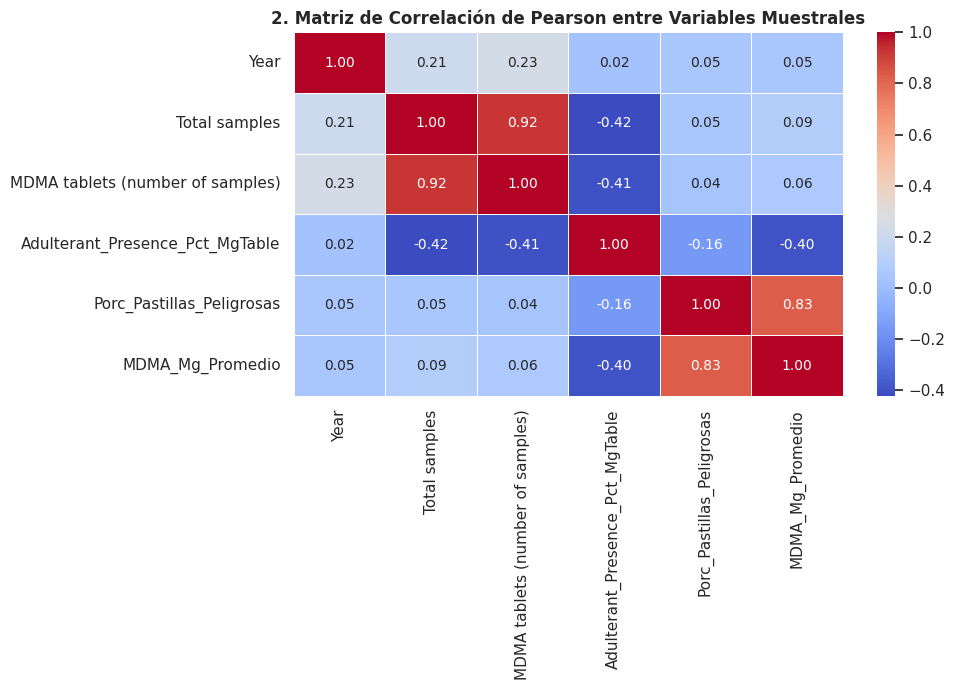

/tmp/ipykernel_535/2217292077.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["Es_Peligrosa"] = (df_ml["MDMA_Mg_Promedio"] > 165).astype(int)



--- 3. REPORTE DE CLASIFICACIÓN DE RIESGO DE SOBREDOSIS ---
               precision    recall  f1-score   support

Riesgo Normal       0.90      0.90      0.90        10
  Alto Riesgo       0.89      0.89      0.89         9

     accuracy                           0.89        19
    macro avg       0.89      0.89      0.89        19
 weighted avg       0.89      0.89      0.89        19



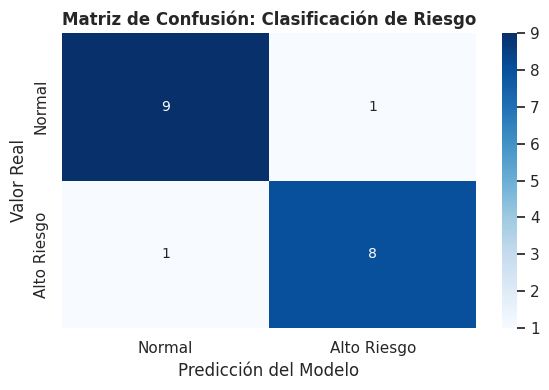

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ==========================================
# 1. IMPORTANCIA DE CARACTERÍSTICAS (FEATURE IMPORTANCE)
# ==========================================
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

importances = pd.Series(rf_reg.feature_importances_, index=features).sort_values(
    ascending=True
)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#2b5c8f")
plt.title(
    "1. Importancia de Variables en la Predicción de MDMA (Random Forest)",
    fontweight="bold",
)
plt.xlabel("Peso Relativo de Importancia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 2. HEATMAP DE CORRELACIONES MULTIVARIADAS
# ==========================================
plt.figure(figsize=(10, 7))
corr_matrix = df_ml[features + ["MDMA_Mg_Promedio"]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
)
plt.title(
    "2. Matriz de Correlación de Pearson entre Variables Muestrales",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# ==========================================
# 3. CLASIFICACIÓN SUPERVISADA DE RIESGO (>200 mg)
# ==========================================
# Crear etiqueta binaria: 1 si es Dosis Peligrosa (>200 mg promedio regional), 0 si no.
df_ml["Es_Peligrosa"] = (df_ml["MDMA_Mg_Promedio"] > 165).astype(int)

y_class = df_ml["Es_Peligrosa"]
X_class = df_ml[features]

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_tr_c, y_tr_c)
y_pred_class = clf.predict(X_te_c)

print("\n--- 3. REPORTE DE CLASIFICACIÓN DE RIESGO DE SOBREDOSIS ---")
print(
    classification_report(
        y_te_c, y_pred_class, target_names=["Riesgo Normal", "Alto Riesgo"]
    )
)

# Matriz de Confusión
cm = confusion_matrix(y_te_c, y_pred_class)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Alto Riesgo"],
    yticklabels=["Normal", "Alto Riesgo"],
)
plt.title("Matriz de Confusión: Clasificación de Riesgo", fontweight="bold")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

/tmp/ipykernel_535/1626002117.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


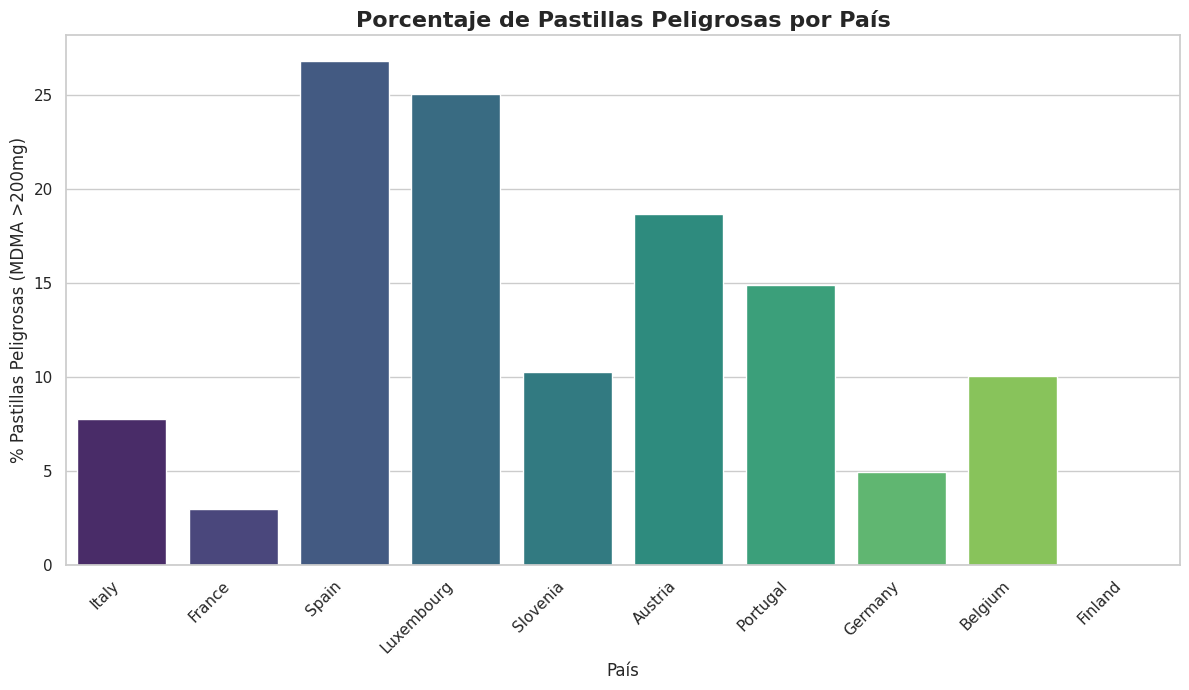

In [ ]:
# Para evitar el SettingWithCopyWarning, trabajaremos con una copia explícita del DataFrame df_ml
df_ml_copy = df_ml.copy()
df_ml_copy["Es_Peligrosa"] = (df_ml_copy["MDMA_Mg_Promedio"] > 165).astype(int)

# Generar un gráfico de barras comparando 'Porc_Pastillas_Peligrosas' por 'Country'
plt.figure(figsize=(12, 7))
sns.barplot(
    data=resumen_pais.reset_index(),
    x="Country",
    y="Porc_Pastillas_Peligrosas",
    hue="Country", # Agregado para resolver el FutureWarning
    palette="viridis",
    legend=False # Agregado para resolver el FutureWarning
)
plt.title(
    "Porcentaje de Pastillas Peligrosas por País",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("País")
plt.ylabel("% Pastillas Peligrosas (MDMA >200mg)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Solución rápida: Asegurar que df_ml sea una copia independiente
df_ml = df_merged.dropna(subset=["MDMA_Mg_Promedio"] + features).copy()

# Y luego asignas la columna sin que salte el warning:
df_ml["Es_Peligrosa"] = (df_ml["MDMA_Mg_Promedio"] > 165).astype(int)

In [ ]:
import pandas as pd

# 1. Crear una copia de trabajo
df_tableau = df_merged.copy()

# 2. Etiquetas Legibles para Clústeres (K-Means)
cluster_names = {
    1: "Riesgo Crítico (Alta Potencia >180mg)",
    0: "Riesgo por Adulteración (~36% Mezcla)",
    2: "Mercado Moderado / Estándar",
}
# Si df_cluster tiene los clústeres, los mapeamos:
if "Cluster" in df_cluster.columns:
    df_tableau["Cluster_ID"] = df_cluster["Cluster"]
    df_tableau["Cluster_Nombre"] = df_tableau["Cluster_ID"].map(cluster_names)

# 3. Categorización del Nivel de Riesgo Sanitarios (Semáforo)
def clasificar_riesgo(row):
    if row["Porc_Pastillas_Peligrosas"] >= 20:
        return "Riesgo Rojo (Peligro Extremo >20% Dosis Altas)"
    elif row["Porc_Pastillas_Peligrosas"] >= 10:
        return "Riesgo Amarillo (Alerta Moderada 10-20%)"
    else:
        return "Riesgo Verde (Control Nivel Bajo <10%)"

df_tableau["Semaforo_Riesgo"] = df_tableau.apply(clasificar_riesgo, axis=1)

# 4. Clasificación del Modelo Predicho (Supervisado)
df_tableau["Evaluacion_Modelo"] = df_tableau["MDMA_Mg_Promedio"].apply(
    lambda x: "Alerta Dosis Peligrosa (>165 mg)"
    if x > 165
    else "Riesgo Convencional"
)

# 5. Indicador de Foco Geográfico (Hotspot)
países_criticos = ["Spain", "Austria", "Luxembourg", "Italy"]
df_tableau["Es_Region_Prioritaria"] = df_tableau["Country"].apply(
    lambda c: "Región de Atención Prioritaria"
    if c in países_criticos
    else "Monitoreo Estándar"
)

# 6. Exportar archivo enriquecido listo para Tableau
filename = "mdma_tableau_ready.csv"
df_tableau.to_csv(filename, index=False)
print(f"¡Dataset enriquecido exportado exitosamente como '{filename}'!")

¡Dataset enriquecido exportado exitosamente como 'mdma_tableau_ready.csv'!
